
입력-예측-손실-역전파-수정

1. 예측한다
2. 얼마나 틀렸는지 계산한다
3. 왜 틀렸는지 계산한다
4. W와 B를 수정한다
5. 반복한다
------------------------------------
1. 예측한다
   y_pred = model(x_train)

2. 얼마나 틀렸는지 계산한다
   loss = criterion(y_pred, y_train)

3. loss를 줄이려면 어떻게 고쳐야 하는지 계산한다
   loss.backward()

4. W와 B 같은 파라미터를 수정한다
   optimizer.step()

5. 기울기를 초기화하고 다음 반복으로 넘어간다
   optimizer.zero_grad()

In [70]:
# =========================================================
# 0. 설치 코드
# Colab에서 한글 폰트와 torchviz를 설치할 때 사용
# 로컬 주피터에서는 안 될 수도 있음
# =========================================================

!sudo apt-get install -y fonts-nanum* | tail -n 1
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib

!pip install torchviz | tail -n 1

0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 39 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/nanum: skipping, looped directory detected
/var/cache/fontconfig: cleaning cache directory
/root/.cache/fontconfig: not cleaning non-existent cache direct

In [71]:
# =========================================================
# 1. 라이브러리 불러오기
# =========================================================

%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

import matplotlib.font_manager as fm

import torch
from torchviz import make_dot

import warnings
warnings.simplefilter('ignore')

In [72]:
# =========================================================
# 2. 그래프 기본 설정
# =========================================================

# 나눔고딕 폰트 경로
path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_name = fm.FontProperties(fname=path, size=10).get_name()

# 그래프 한글 폰트 설정
plt.rcParams['font.family'] = font_name

# 그래프 글자 크기
plt.rcParams['font.size'] = 14

# 그래프 크기
plt.rcParams['figure.figsize'] = (6, 6)

# 그래프 격자 표시
plt.rcParams['axes.grid'] = True

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 넘파이 출력 자릿수 설정
np.set_printoptions(suppress=True, precision=4)

1단계: 경사하강법을 3D 그래프로 보기

In [ ]:
# =========================================================
# 3. 경사하강법 예시용 손실 함수 만들기
# =========================================================

# 손실 함수 L
# u, v 값을 넣으면 손실값을 계산함
def L(u, v):
    return 3 * u**2 + 3 * v**2 - u * v + 7 * u - 7 * v + 10


# u 방향 기울기
# L을 u에 대해 미분한 값
def Lu(u, v):
    return 6 * u - v + 7


# v 방향 기울기
# L을 v에 대해 미분한 값
def Lv(u, v):
    return 6 * v - u - 7


# -5부터 5까지 501개 숫자를 생성
u = np.linspace(-5, 5, 501)
v = np.linspace(-5, 5, 501)

# 2차원 좌표판 생성
U, V = np.meshgrid(u, v)

# 각 좌표에서 손실값 계산
Z = L(U, V)

In [ ]:
# =========================================================
# 4. 경사하강법 시뮬레이션
# =========================================================

# 시작 위치
# 여기서는 W를 [u, v] 좌표처럼 사용
W = np.array([4.0, 4.0])

# 이동 경로 기록용 리스트
W1 = [W[0]]
W2 = [W[1]]

# 반복 횟수
N = 21

# 학습률
# alpha는 lr과 같은 의미
alpha = 0.05

# 경사하강법 반복
for i in range(N):
    # 현재 위치의 기울기 계산
    grad = np.array([Lu(W[0], W[1]), Lv(W[0], W[1])])

    # 손실이 줄어드는 방향으로 이동
    W = W - alpha * grad

    # 이동한 위치 기록
    W1.append(W[0])
    W2.append(W[1])

In [ ]:
# =========================================================
# 5. 경사하강법 이동 경로를 3D로 시각화
# =========================================================

# 앞의 11개 이동 경로만 사용
n_loop = 11

WW1 = np.array(W1[:n_loop])
WW2 = np.array(W2[:n_loop])
ZZ = L(WW1, WW2)

# 3D 그래프 생성
fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection='3d')

# z축 범위 설정
ax.set_zlim(0, 250)

# 축 이름 설정
ax.set_xlabel('W')
ax.set_ylabel('B')
ax.set_zlabel('loss')

# 그래프 보는 각도 설정
ax.view_init(50, 240)

# 격자선 두께 설정
ax.xaxis._axinfo["grid"]['linewidth'] = 2.
ax.yaxis._axinfo["grid"]['linewidth'] = 2.
ax.zaxis._axinfo["grid"]['linewidth'] = 2.

# 손실 함수 지형 그리기
ax.contour3D(U, V, Z, 100, cmap='Blues', alpha=0.7)

# 경사하강법 이동 경로 그리기
ax.plot3D(WW1, WW2, ZZ, 'o-', c='k', alpha=1, markersize=7)

plt.show()

2단계: 키와 몸무게 데이터 준비

In [69]:
# =========================================================
# 6. 샘플 데이터 만들기
# =========================================================

# 데이터 형식: [신장, 체중]
sampleData1 = np.array([
    [166, 58.7],
    [176.0, 75.7],
    [171.0, 62.1],
    [173.0, 70.4],
    [169.0, 60.1]
])

print(sampleData1)

[[166.   58.7]
 [176.   75.7]
 [171.   62.1]
 [173.   70.4]
 [169.   60.1]]


In [73]:
# =========================================================
# 7. 입력 데이터 x와 정답 데이터 y로 분리
# =========================================================

x = sampleData1[:, 0]
y = sampleData1[:, 1]

print(x)
print(y)

[166. 176. 171. 173. 169.]
[58.7 75.7 62.1 70.4 60.1]


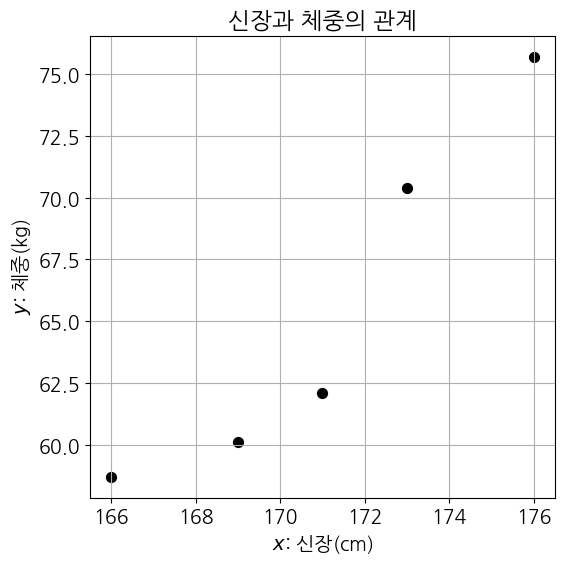

In [74]:
# =========================================================
# 8. 원본 데이터 산포도 그리기
# =========================================================

plt.scatter(x, y, c='k', s=50)

plt.xlabel('$x$: 신장(cm)')
plt.ylabel('$y$: 체중(kg)')
plt.title('신장과 체중의 관계')
plt.show()

3단계: 데이터 중심 맞추기

In [75]:
# =========================================================
# 9. 데이터 평균 확인
# =========================================================

print(x.mean())
print(y.mean())

171.0
65.4


In [76]:
# =========================================================
# 10. 평균을 빼서 데이터 중심을 0으로 맞추기
# =========================================================

X = x-x.mean()
Y = y-y.mean()

print(X)
print(Y)

[-5.  5.  0.  2. -2.]
[-6.7 10.3 -3.3  5.  -5.3]


Text(0.5, 1.0, '데이터 가공 후 신장과 체중의 관계')

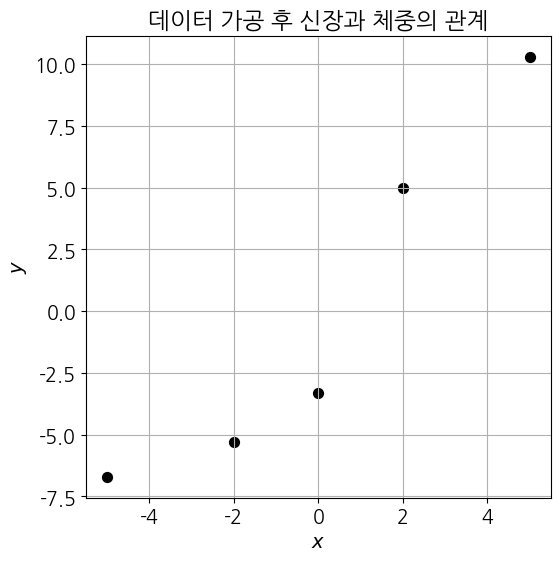

In [77]:
# =========================================================
# 11. 변환된 데이터 산포도 확인
# =========================================================

plt.scatter(X, Y, c='k', s=50)
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title('데이터 가공 후 신장과 체중의 관계')

4단계: PyTorch Tensor로 변환

In [78]:
# =========================================================
# 12. NumPy 배열을 PyTorch Tensor로 변환
# =========================================================

X = torch.tensor(X).float()
Y = torch.tensor(Y).float()

print(X)
print(Y)

tensor([-5.,  5.,  0.,  2., -2.])
tensor([-6.7000, 10.3000, -3.3000,  5.0000, -5.3000])


In [80]:
# =========================================================
# 13. 학습할 파라미터 W, B 만들기
# =========================================================

# W = Weight 가중치, 기울기
# B = Bias 편향, 절편
# requires_grad = True = 기울기를 계산하겠다는 뜻

W = torch.tensor(1.0, requires_grad=True).float()
B = torch.tensor(1.0, requires_grad=True).float()

print(W)
print(B)

tensor(1., requires_grad=True)
tensor(1., requires_grad=True)


In [81]:
# =========================================================
# 14. 예측 함수 만들기
# =========================================================

def pred(X):
  return W * X + B

Yp = pred(X)

print(Yp)


tensor([-4.,  6.,  1.,  3., -1.], grad_fn=<AddBackward0>)


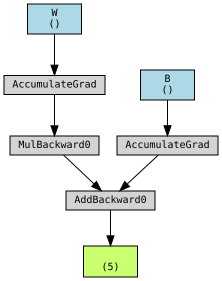

In [83]:
# =========================================================
# 15. 예측 계산 그래프 보기
# =========================================================

# params는 학습 대상 파라미터를 표시하기 위한 딕셔너리
params = {'W':W, 'B':B}

# Yp가 어떤 계산 과정을 거쳐 만들어졌는지 시각화
g = make_dot(Yp, params=params)

display(g)

6단계: 손실 함수 만들기

In [85]:
# =========================================================
# 16. MSE 손실 함수 만들기
# =========================================================

# mse = Mean Squared Error
# 평균 제곱 오차
def mse(Yp, Y):
  loss = ((Yp - Y)**2).mean()
  return loss

In [86]:
# =========================================================
# 17. 현재 예측값의 손실 계산
# =========================================================

loss = mse(Yp, Y)

print(loss)

tensor(13.3520, grad_fn=<MeanBackward0>)


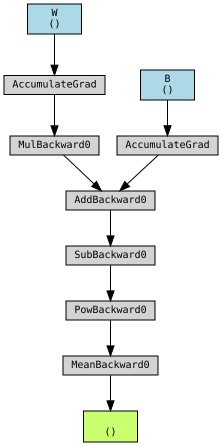

In [87]:
# =========================================================
# 18. 손실 계산 그래프 보기
# =========================================================

params = {'W':W, 'B':B}

g = make_dot(loss, params=params)

display(g)

7단계: 역전파로 기울기 계산

In [88]:
# =========================================================
# 19. 역전파 실행
# =========================================================

# loss.backward()는 W와 B의 기울기를 계산함
loss.backward()

# W와 B의 기울기 확인
print(W.grad)
print(B.grad)

tensor(-19.0400)
tensor(2.0000)


8단계: 파라미터 직접 수정하기

In [89]:
# =========================================================
# 20. 학습률 설정
# =========================================================

# lr = learning rate
# 한 번에 얼마나 움직일지 정하는 값
lr = 0.001

In [90]:
# =========================================================
# 21. 잘못된 파라미터 수정 방식
# =========================================================

# 이 코드는 에러 확인용임
# requires_grad=True인 W, B를 바로 in-place 수정하려고 해서 오류가 남

try:
    W -= lr * W.grad
    B -= lr * B.grad

except RuntimeError as e:
    print(e)

a leaf Variable that requires grad is being used in an in-place operation.


In [91]:
# =========================================================
# 22. 올바른 파라미터 수정 방식
# =========================================================

# torch.no_grad() 안에서는 계산 기록을 남기지 않음
with torch.no_grad():
  W -= lr * W.grad
  B -= lr * B.grad

# 사용한 기울기는 반드시 초기화
W.grad.zero_()
B.grad.zero_()

tensor(0.)

In [92]:
# =========================================================
# 23. 수정된 W, B와 초기화된 grad 확인
# =========================================================

print(W)
print(B)

print(W.grad)
print(B.grad)

tensor(1.0190, requires_grad=True)
tensor(0.9980, requires_grad=True)
tensor(0.)
tensor(0.)


9단계: 반복 학습 직접 구현

In [93]:
# =========================================================
# 24. 반복 학습을 위한 초기화
# =========================================================

# W, B 다시 초기화
W = torch.tensor(1.0, requires_grad = True).float()
B = torch.tensor(1.0, requires_grad = True).float()

# 반복 횟수
num_epochs = 500

# 학습률
lr = 0.001

# 손실 기록용 배열
# 첫 번째 열: epoch
# 두 번째 열: loss
history = np.zeros((0, 2))

In [94]:
# =========================================================
# 25. 직접 구현한 학습 루프
# =========================================================

for epoch in range(num_epochs):
  # 1. 예측 계산
  Yp = pred(X)

  # 2. 손실 계산
  loss = mse(Yp, Y)

  # 3. 역전파로 기울기 계산
  loss.backward()

  # 4. 기울기를 이용해 W, B 수정
  with torch.no_grad():
    W -= lr * W.grad
    B -= lr * B.grad

  # 5. 기울기 초기화
  W.grad.zero_()
  B.grad.zero_()

  # 6. 10번마다 손실 기록
  if epoch % 10 == 0:
    item = np.array([epoch, loss.item()])
    history = np.vstack((history, item))

    print(f'epoch: {epoch}, loss: {loss:.4f}')

epoch: 0, loss: 13.3520
epoch: 10, loss: 10.3855
epoch: 20, loss: 8.5173
epoch: 30, loss: 7.3364
epoch: 40, loss: 6.5858
epoch: 50, loss: 6.1047
epoch: 60, loss: 5.7927
epoch: 70, loss: 5.5868
epoch: 80, loss: 5.4476
epoch: 90, loss: 5.3507
epoch: 100, loss: 5.2805
epoch: 110, loss: 5.2275
epoch: 120, loss: 5.1855
epoch: 130, loss: 5.1507
epoch: 140, loss: 5.1208
epoch: 150, loss: 5.0943
epoch: 160, loss: 5.0703
epoch: 170, loss: 5.0480
epoch: 180, loss: 5.0271
epoch: 190, loss: 5.0074
epoch: 200, loss: 4.9887
epoch: 210, loss: 4.9708
epoch: 220, loss: 4.9537
epoch: 230, loss: 4.9373
epoch: 240, loss: 4.9217
epoch: 250, loss: 4.9066
epoch: 260, loss: 4.8922
epoch: 270, loss: 4.8783
epoch: 280, loss: 4.8650
epoch: 290, loss: 4.8522
epoch: 300, loss: 4.8399
epoch: 310, loss: 4.8281
epoch: 320, loss: 4.8167
epoch: 330, loss: 4.8058
epoch: 340, loss: 4.7953
epoch: 350, loss: 4.7853
epoch: 360, loss: 4.7756
epoch: 370, loss: 4.7663
epoch: 380, loss: 4.7574
epoch: 390, loss: 4.7488
epoch: 40

In [95]:
# =========================================================
# 26. 최종 W, B와 손실 확인
# =========================================================

print('W', W.data.numpy())
print('B', B.data.numpy())

print(f'초기상태: 손실 : {history[0, 1]:.4f}')
print(f'최종상태: 손실 : {history[-1, 1]:.4f}')

W 1.820683
B 0.3675114
초기상태: 손실 : 13.3520
최종상태: 손실 : 4.6796


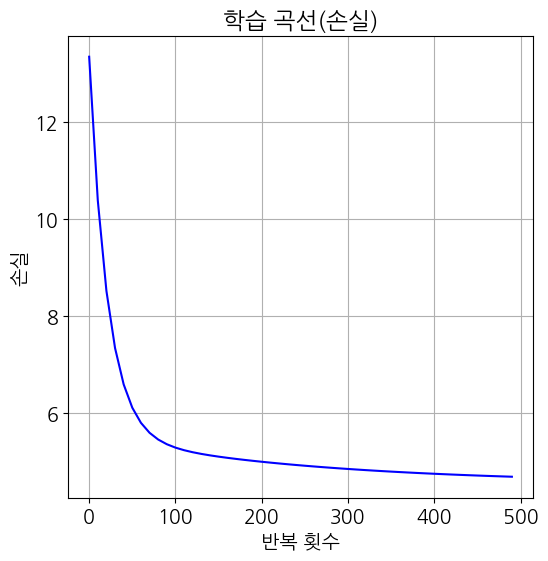

In [96]:
# =========================================================
# 27. 손실 그래프 그리기
# =========================================================

plt.plot(history[:, 0], history[:, 1], 'b')

plt.xlabel('반복 횟수')
plt.ylabel('손실')
plt.title('학습 곡선(손실)')

plt.show()

11단계: 학습된 직선 그리기

In [99]:
# =========================================================
# 28. 가공 후 데이터 기준 회귀 직선 그리기
# =========================================================

# X의 최솟값과 최댓값 구하기
X_max = X.max()
X_min = X.min()

# 직선을 그리기 위한 x 범위 만들기
X_range = np.array((X_min, X_max))
X_range = torch.from_numpy(X_range).float()

print(X_range)

# X_range에 대한 예측값 계산
Y_range = pred(X_range)

print(Y_range.data)

tensor([-5.,  5.])
tensor([-8.7359,  9.4709])


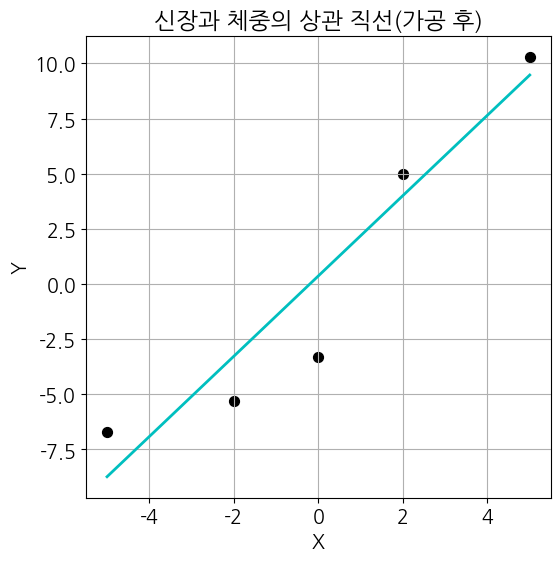

In [100]:
# =========================================================
# 29. 가공 후 데이터 산포도 + 회귀 직선
# =========================================================

plt.scatter(X, Y, c='k', s=50)

plt.xlabel('X')
plt.ylabel('Y')

# lw = line width, 선 두께
# c='c'는 cyan, 청록색
plt.plot(X_range.data, Y_range.data, lw=2, c='c')

plt.title('신장과 체중의 상관 직선(가공 후)')

plt.show()

In [101]:
# =========================================================
# 30. 원래 데이터 기준으로 다시 변환
# =========================================================

# X는 x에서 평균을 뺀 값이므로 원래 값으로 돌아가려면 평균을 더함
x_range = X_range + x.mean()

# Y도 y에서 평균을 뺀 값이므로 평균을 더함
yp_range = Y_range + y.mean()

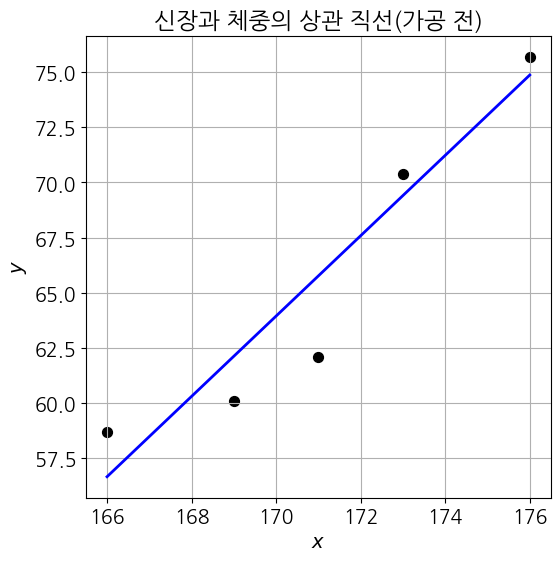

In [102]:
# =========================================================
# 31. 원본 데이터 산포도 + 회귀 직선
# =========================================================

plt.scatter(x, y, c='k', s=50)

plt.xlabel('$x$')
plt.ylabel('$y$')

plt.plot(x_range, yp_range.data, lw=2, c='b')

plt.title('신장과 체중의 상관 직선(가공 전)')

plt.show()

12단계: Optimizer 사용하기

In [103]:
# =========================================================
# 32. optimizer를 사용하기 위한 초기화
# =========================================================

# W, B 다시 초기화
W = torch.tensor(1.0, requires_grad = True).float()
B = torch.tensor(1.0, requires_grad = True).float()

# 반복 횟수
num_epochs = 500

# 학습률
lr = 0.001

import torch.optim as optim

# SGD optimiser 생성
# [W, B]를 optimiser가 관리하게 함
optimizer = optim.SGD([W, B], lr=lr)

# 손실 기록용 배열
history = np.zeros((0, 2))

In [105]:
# =========================================================
# 33. optimizer를 사용한 학습 루프
# =========================================================

for epoch in range(num_epochs):
  # 1. 예측 계산
  Yp = pred(X)

  # 2. 손실 게산
  loss = mse(Yp, Y)

  # 3. 역전파로 기울기 계산
  loss.backward()

  # 4. optimizer가 W, B를 자동으로 업데이트
  optimizer.step()

  # 5. optimizer가 관리하는 파라미터들의 기울기 초기화
  optimizer.zero_grad()

  # 6. 10마다 손실 기록
  if epoch % 10 == 0:
    item = np.array((epoch, loss.item()))
    history = np.vstack((history, item))

    print(f'epoch = {epoch} loss = {loss.item():.4f}')

epoch = 0 loss = 12.9897
epoch = 10 loss = 9.9298
epoch = 20 loss = 8.2298
epoch = 30 loss = 7.1541
epoch = 40 loss = 6.4694
epoch = 50 loss = 6.0297
epoch = 60 loss = 5.7435
epoch = 70 loss = 5.5539
epoch = 80 loss = 5.4251
epoch = 90 loss = 5.3347
epoch = 100 loss = 5.2686
epoch = 110 loss = 5.2182
epoch = 120 loss = 5.1780
epoch = 130 loss = 5.1444
epoch = 140 loss = 5.1153
epoch = 150 loss = 5.0893
epoch = 160 loss = 5.0657
epoch = 170 loss = 5.0437
epoch = 180 loss = 5.0231
epoch = 190 loss = 5.0036
epoch = 200 loss = 4.9850
epoch = 210 loss = 4.9673
epoch = 220 loss = 4.9504
epoch = 230 loss = 4.9342
epoch = 240 loss = 4.9186
epoch = 250 loss = 4.9037
epoch = 260 loss = 4.8893
epoch = 270 loss = 4.8756
epoch = 280 loss = 4.8624
epoch = 290 loss = 4.8497
epoch = 300 loss = 4.8375
epoch = 310 loss = 4.8258
epoch = 320 loss = 4.8145
epoch = 330 loss = 4.8037
epoch = 340 loss = 4.7933
epoch = 350 loss = 4.7833
epoch = 360 loss = 4.7737
epoch = 370 loss = 4.7645
epoch = 380 loss = 4.7

In [107]:
# =========================================================
# 34. optimizer 사용 결과 확인
# =========================================================

print('W', W.data.numpy())
print('B', B.data.numpy())

print(f'초기상태: 손실 : {history[0, 1]:.4f}')
print(f'최종상태: 손실 : {history[-1, 1]:.4f}')

W 1.8206832
B 0.36604
초기상태: 손실 : 12.9897
최종상태: 손실 : 4.6785


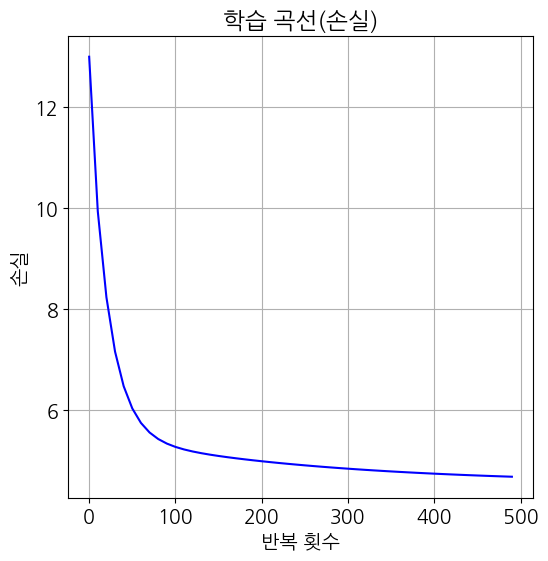

In [108]:
# =========================================================
# 35. optimizer 사용 시 손실 그래프
# =========================================================

plt.plot(history[:, 0], history[:, 1], 'b')

plt.xlabel('반복 횟수')
plt.ylabel('손실')
plt.title('학습 곡선(손실)')

plt.show()

13단계: Momentum 적용하기

In [109]:
# =========================================================
# 36. 기본 SGD 결과 저장
# =========================================================

history_default = history

In [111]:
# =========================================================
# 37. Momentum 적용을 위한 초기화
# =========================================================

# W, B 다시 초기화
W = torch.tensor(1.0, requires_grad=True).float()
B = torch.tensor(1.0, requires_grad=True).float()

# momentum=0.9 옵션 추가
# momentum은 이전 이동 방향의 관성을 반영함
optimizer = optim.SGD([W, B], lr=lr, momentum=0.9)

# momentum 결과 기록용 배열
history_momentum = np.zeros((0, 2))

In [112]:
# =========================================================
# 38. Momentum 적용 학습 루프
# =========================================================

for epoch in range(num_epochs):
    # 1. 예측 계산
    Yp = pred(X)

    # 2. 손실 계산
    loss = mse(Yp, Y)

    # 3. 기울기 계산
    loss.backward()

    # 4. 파라미터 수정
    optimizer.step()

    # 5. 기울기 초기화
    optimizer.zero_grad()

    # 6. 10번마다 손실 기록
    if epoch % 10 == 0:
        item = np.array([epoch, loss.item()])
        history_momentum = np.vstack((history_momentum, item))

        print(f'epoch = {epoch} loss = {loss:.4f}')

epoch = 0 loss = 13.3520
epoch = 10 loss = 5.7585
epoch = 20 loss = 5.9541
epoch = 30 loss = 5.0276
epoch = 40 loss = 4.8578
epoch = 50 loss = 4.7052
epoch = 60 loss = 4.6327
epoch = 70 loss = 4.5940
epoch = 80 loss = 4.5698
epoch = 90 loss = 4.5574
epoch = 100 loss = 4.5495
epoch = 110 loss = 4.5452
epoch = 120 loss = 4.5426
epoch = 130 loss = 4.5411
epoch = 140 loss = 4.5403
epoch = 150 loss = 4.5398
epoch = 160 loss = 4.5395
epoch = 170 loss = 4.5393
epoch = 180 loss = 4.5392
epoch = 190 loss = 4.5391
epoch = 200 loss = 4.5391
epoch = 210 loss = 4.5391
epoch = 220 loss = 4.5391
epoch = 230 loss = 4.5390
epoch = 240 loss = 4.5390
epoch = 250 loss = 4.5390
epoch = 260 loss = 4.5390
epoch = 270 loss = 4.5390
epoch = 280 loss = 4.5390
epoch = 290 loss = 4.5390
epoch = 300 loss = 4.5390
epoch = 310 loss = 4.5390
epoch = 320 loss = 4.5390
epoch = 330 loss = 4.5390
epoch = 340 loss = 4.5390
epoch = 350 loss = 4.5390
epoch = 360 loss = 4.5390
epoch = 370 loss = 4.5390
epoch = 380 loss = 4.5

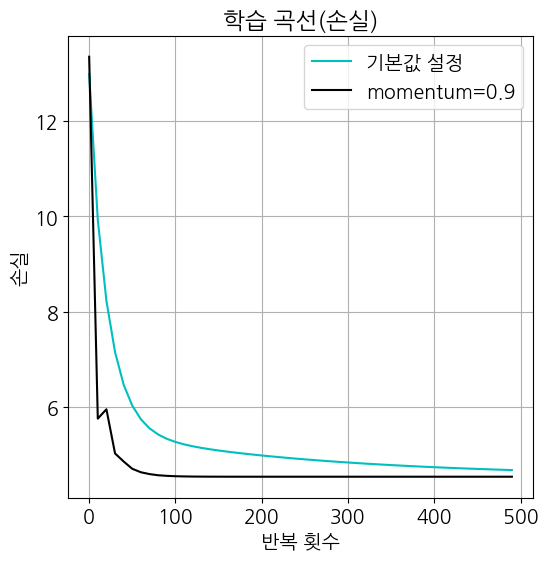

In [113]:
# =========================================================
# 39. 기본 SGD와 Momentum SGD 비교
# =========================================================

plt.plot(
    history_default[:, 0],
    history_default[:, 1],
    'c',
    label='기본값 설정'
)

plt.plot(
    history_momentum[:, 0],
    history_momentum[:, 1],
    'k',
    label='momentum=0.9'
)

plt.xlabel('반복 횟수')
plt.ylabel('손실')
plt.legend()
plt.title('학습 곡선(손실)')

plt.show()

14단계: 국소 최적화 문제 예시

In [115]:
# =========================================================
# 40. 국소 최적화 문제 예시 함수
# =========================================================

def f(x):
    return x * (x + 1) * (x + 2) * (x - 2)

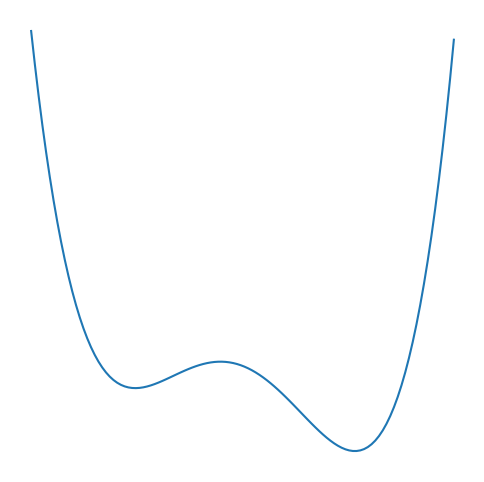

In [116]:
# =========================================================
# 41. 함수 그래프 그리기
# =========================================================

x = np.arange(-3, 2.7, 0.05)
y = f(x)

plt.plot(x, y)

# 축 숨기기
plt.axis('off')

plt.show()

Train / Validation / Test

In [117]:
# =========================================================
# 1. 라이브러리 불러오기
# =========================================================

import torch
import math
import random

import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

In [118]:
# =========================================================
# 2. 사인파 데이터 만들기
# =========================================================

# 랜덤값을 고정해서 실행할 때마다 같은 결과가 나오게 함
torch.manual_seed(0)

# 데이터 개수
N = 600

# -3π부터 3π까지 600개의 x값 생성
# unsqueeze(1)로 shape을 (600, 1)로 만듦
x = torch.linspace(-3 * math.pi, 3 * math.pi, N).unsqueeze(1)

# y = sin(x) + 잡음
# torch.randn_like(x)는 x와 같은 모양의 랜덤 잡음을 만듦
y = torch.sin(x) + 0.2 * torch.randn_like(x)

In [119]:
# =========================================================
# 3. Train / Validation / Test 데이터 분할
# =========================================================

# 전체 데이터 중 40%를 임시 데이터로 빼고,
# 60%는 학습 데이터로 사용
X_train, X_temp, y_train, y_temp = train_test_split(
    x.numpy(),
    y.numpy(),
    test_size=0.4,
    random_state=42
)

# 임시 데이터 40%를 다시 반으로 나눔
# 결과적으로 Validation 20%, Test 20%
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42
)

In [120]:
# =========================================================
# 4. NumPy 배열을 다시 PyTorch Tensor로 변환
# =========================================================

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [121]:
# =========================================================
# 5. MLP 모델 생성 함수
# =========================================================

def make_mlp(hidden):
    return nn.Sequential(
        nn.Linear(1, hidden),
        nn.ReLU(),

        nn.Linear(hidden, hidden),
        nn.ReLU(),

        nn.Linear(hidden, 1)
    )

In [122]:
# =========================================================
# 6. 작은 모델과 큰 모델 생성
# =========================================================

small = make_mlp(hidden=8)     # 작은 모델
big = make_mlp(hidden=128)     # 큰 모델

In [123]:
# =========================================================
# 7. 학습 함수 정의
# =========================================================

def train(model, Xtr, ytr, Xva, yva, epochs=600, lr=1e-3):
    # Adam optimizer 생성
    opt = optim.Adam(model.parameters(), lr=lr)

    # MSE 손실 함수 생성
    loss_fn = nn.MSELoss()

    # 학습 손실, 검증 손실 기록용 리스트
    tr_hist = []
    va_hist = []

    # epochs만큼 반복 학습
    for ep in range(epochs):
        # -------------------------
        # 1. 학습 모드
        # -------------------------
        model.train()

        # 이전 기울기 초기화
        opt.zero_grad()

        # 예측
        pred = model(Xtr)

        # 학습 데이터 기준 손실 계산
        loss = loss_fn(pred, ytr)

        # 역전파
        loss.backward()

        # 파라미터 수정
        opt.step()

        # -------------------------
        # 2. 평가 모드
        # -------------------------
        model.eval()

        # 평가할 때는 기울기 계산 필요 없음
        with torch.no_grad():
            v = loss_fn(model(Xva), yva).item()

        # 손실 기록
        tr_hist.append(loss.item())
        va_hist.append(v)

    return tr_hist, va_hist

In [124]:
# =========================================================
# 8. 작은 모델과 큰 모델 학습
# =========================================================

tr_s, va_s = train(
    small,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=400
)

tr_b, va_b = train(
    big,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=400
)

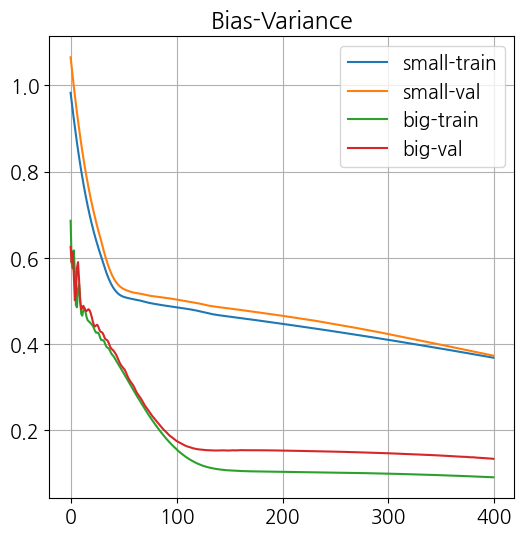

In [125]:
# =========================================================
# 9. Train loss와 Validation loss 비교 그래프
# =========================================================

plt.figure()

plt.plot(tr_s, label='small-train')
plt.plot(va_s, label='small-val')

plt.plot(tr_b, label='big-train')
plt.plot(va_b, label='big-val')

plt.legend()
plt.title('Bias-Variance')

plt.show()

In [126]:
# =========================================================
# 10. 최종 테스트 MSE 계산 함수
# =========================================================

def mse(model, X, y):
    with torch.no_grad():
        return nn.MSELoss()(model(X), y).item()

In [127]:
# =========================================================
# 11. 최종 테스트 결과 출력
# =========================================================

print("Small Test MSE:", mse(small, X_test, y_test))
print("Big   Test MSE:", mse(big, X_test, y_test))

Small Test MSE: 0.38624173402786255
Big   Test MSE: 0.135029137134552
